In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import seaborn as sns
from fontTools.diff import color
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter

# fix errore ascii font
mpl.rcParams['font.family'] = 'sans-serif'

<div style="color:#666;">

### Descrizione del progetto

##### Prima dell’analisi sono state effettuate alcune scelte metodologiche. In particolare, è stata considerata esclusivamente la Sentiment Polarity, mentre la Sentiment Subjectivity non è stata analizzata poiché l’obiettivo era valutare il sentiment generale espresso dagli utenti e non il grado di soggettività delle recensioni. Inoltre, la colonna Genres è stata esclusa dall’analisi in quanto contiene numerosi valori misti e combinazioni di generi che avrebbero reso meno chiara e significativa l’interpretazione dei risultati.

##### Inizialmente è stata calcolata la matrice di correlazione di Spearman per individuare anche eventuali correlazioni monotone non lineari. Successivamente sono state analizzate le correlazioni più rilevanti: le applicazioni con rating elevato presentano mediamente un numero maggiore di reviews e, all’aumentare del rating, tende ad aumentare anche la sentiment polarity.

##### Le reviews, invece, non risultano influenzate dalla dimensione delle applicazioni, mentre sono fortemente legate al numero di installazioni: all’aumentare delle installazioni cresce anche il numero delle reviews. Non emerge inoltre una relazione significativa tra reviews, prezzo e sentiment polarity tale da consentire l’individuazione di trend o pattern utili.

##### La correlazione positiva individuata dalla heatmap tra la dimensione delle applicazioni e il numero di installazioni si dimostra anch’essa poco utile a fini decisionali, a causa dell’elevata dispersione dei valori e dell’assenza di un trend chiaramente identificabile. Una situazione analoga si osserva nella correlazione tra dimensione delle applicazioni e sentiment polarity, dove la forte dispersione dei dati non permette di individuare relazioni significative.

##### Anche le correlazioni negative evidenziate dalla matrice tra installazioni, prezzo e sentiment polarity non mostrano tendenze chiare. Si osserva solamente una buona distribuzione delle applicazioni tra le diverse fasce di installazione e un sentiment mediamente positivo per la maggior parte delle applicazioni.

##### Successivamente è stata svolta un’analisi delle categorie con il maggior numero medio di recensioni, dalla quale emergono principalmente le categorie Social, Communication, Game e Photography. Tra le applicazioni con i volumi di recensioni più elevati si distinguono Facebook, WhatsApp, Instagram, Messenger, YouTube, Subway Surfers, Clash of Clans e Clash Royale.

##### Le applicazioni presenti nel Play Store appartengono prevalentemente alla fascia Everyone, risultando quindi adatte a utenti di tutte le età. La seconda fascia più rappresentata è Teen, seguita da Mature 17+.

##### Sono state inoltre individuate le categorie più rappresentate nel Play Store e analizzati i prezzi delle relative applicazioni a pagamento. Le categorie più presenti risultano essere Family, Game, Tools, Business, Medical, Personalization, Productivity, Lifestyle, Finance e Sports, con prezzi generalmente compresi tra 1 e 5 euro. L’analisi mostra tuttavia che le categorie più popolose del Google Play Store non coincidono necessariamente con quelle che presentano il rating medio più elevato. Al contrario, molte delle categorie con le valutazioni migliori sono meno rappresentate all’interno dello store.

##### L’analisi delle applicazioni gratuite ed a pagamento evidenzia che le app a pagamento sono concentrate principalmente nelle categorie Family, Game, Tools, Medical e Personalization e rappresentano circa l’8% delle applicazioni del Play Store, mentre le applicazioni gratuite costituiscono il restante 92%. La maggior parte delle app a pagamento presenta un prezzo compreso tra 1 e 25 euro. Sono inoltre presenti alcuni outlier, con prezzi tra 25 e 400 euro: la maggior parte appartiene alla serie “I’m Rich”, una famiglia di applicazioni prive di particolari funzionalità e commercializzate a prezzi molto elevati. Tra queste, la più costosa è “I’m Rich – Trump Edition”, con un prezzo di 400 euro.

##### L’ultima fase dell’analisi è dedicata all’individuazione di possibili opportunità di ingresso nel mercato. Le categorie selezionate presentano un buon equilibrio tra numero di installazioni, numero di applicazioni e sentiment medio delle recensioni. Le categorie che mostrano il livello di concorrenza più contenuto sono Art & Design, House & Home, Weather e Libraries & Demo. Seguono, con un numero di applicazioni leggermente superiore, Education, Food & Drink, Maps & Navigation, Books & Reference, Travel & Local e Health & Fitness.
</div>

<div style="color:#666;">

#### Download csv e creazione df aggiornato con media sentiment polarity e subjectivity

</div>

In [2]:
path = kagglehub.dataset_download("lava18/google-play-store-apps")

google_play_store = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "lava18/google-play-store-apps", "googleplaystore.csv")
google_play_reviews = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "lava18/google-play-store-apps", "googleplaystore_user_reviews.csv")

df = google_play_store.copy()
# creazione nuovo df con app e medie sentiment analysis
reviews = (google_play_reviews.groupby('App').agg(
    mean_sent_polarity=('Sentiment_Polarity', 'mean'),
    mean_sent_subjectivity=('Sentiment_Subjectivity', 'mean')).reset_index())

<div style="color:#666;">

#### Esplorazione tipi di dato

</div>

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


<div style="color:#666;">

#### Cancellazione duplicati

</div>

In [4]:
df = df.drop_duplicates()

<div style="color:#666;">

#### Rimozione riga con valori misti </div>

In [5]:
df[df['Installs'] == 'Free']
df.drop(index=10472, inplace=True)

<div style="color:#666;">

#### Unione dataset App e Reviews
##### Aggiunta del dataset sulle recensioni delle app per integrazione recensioni e sentiment analysis </div>

In [6]:
df = df.merge(reviews, on='App', how='left')

<div style="color:#666;">

#### Data processing</div>

In [7]:
duplicati = df.duplicated(subset='App').sum()
print(f"Duplicati presenti: {duplicati}")

Duplicati presenti: 698


In [8]:
# normalizzazione valori
# si presume che l'osservazione con più recensioni sia quella più aggiornata
df = df.sort_values('Reviews', ascending=False)
df = df.drop_duplicates(subset='App', keep='first')

# sostituzione tipi
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# sostituzione tipi, simbolo 'M' e correzione valori
def convert(size):
    if pd.isna(size):
        return np.nan
    if size == 'Varies with device':
        return np.nan
    if 'M' in size:
        return float(size.replace('M', ''))
    if 'k' in size:
        return float(size.replace('k', '')) / 1024 # conversione in MB
    return np.nan
df['Size'] = df['Size'].apply(convert)

# sostituzione tipi, simbolo '+'
df['Installs'] = (df['Installs'].str.replace(',', '', regex=False).str.replace('+', '', regex=False))
df['Installs'] = df['Installs'].astype(float)

# sostituzione tipi, simbolo '$'
df['Price'] = (df['Price'].str.replace('$', '', regex=False))
df['Price'] = df['Price'].astype(float)

# sotituzione in formato data
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

# modifica caratteri speciali
df.loc[df['App'] == "💎 I'm rich", 'App'] = 'Diamond Im Rich'
df.loc[df['App'] == "I'm Rich/Eu sou Rico/أنا غني/我很有錢", 'App'] = "I'm Rich/Eu sou Rico"

# sostituzione '_' con spazio
df['Category'] = df['Category'].str.replace('_', ' ', regex=False)

In [9]:
duplicati = df.duplicated(subset='App').sum()
print(f"Duplicati presenti: {duplicati}")

Duplicati presenti: 0


<div style="color:#666;">

#### Tipi di dato dopo conversione</div>

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 9659 entries, 2627 to 8128
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   App                     9659 non-null   str           
 1   Category                9659 non-null   str           
 2   Rating                  8196 non-null   float64       
 3   Reviews                 9659 non-null   int64         
 4   Size                    8432 non-null   float64       
 5   Installs                9659 non-null   float64       
 6   Type                    9658 non-null   str           
 7   Price                   9659 non-null   float64       
 8   Content Rating          9659 non-null   str           
 9   Genres                  9659 non-null   str           
 10  Last Updated            9659 non-null   datetime64[us]
 11  Current Ver             9651 non-null   str           
 12  Android Ver             9657 non-null   str           
 13  m

<div style="color:#666;">

#### Controllo specifico per valori nulli
##### il dataset google play store contiene più app del dataset sulle reviews, esistono quindi tanti valori null a causa della mancata corrispondenza dopo unione dei due dataset
</div>

In [11]:
df.isna().sum().sort_values(ascending=False)

mean_sent_polarity        8843
mean_sent_subjectivity    8843
Rating                    1463
Size                      1227
Current Ver                  8
Android Ver                  2
Type                         1
App                          0
Category                     0
Reviews                      0
Installs                     0
Price                        0
Content Rating               0
Genres                       0
Last Updated                 0
dtype: int64

<div style="color:#666;">

#### La matrice di correlazione evidenzia diverse relazioni tra le variabili del dataset. Le principali correlazioni analizzate sono riportate di seguito.

####  - Correlazioni positive
##### - Forte correlazione positiva tra Reviews e Installs.
##### - Correlazione positiva moderata tra Rating e Sentiment Polarity.
##### - Debole correlazione positiva tra Rating e Reviews.
##### - Debole correlazione positiva tra Size e Installs (non chiaramente confermata dallo scatterplot).
##### - Debole correlazione positiva tra Reviews e Size (non confermata dall'analisi grafica).
####  - Correlazioni negative
##### - Debole correlazione negativa tra Reviews e Price.
##### - Debole correlazione negativa tra Reviews e Sentiment Polarity.
##### - Correlazione negativa moderata tra Size e Sentiment Polarity.
##### - Debole correlazione negativa tra Installs e Price.
##### - Debole correlazione negativa tra Installs e Sentiment Polarity.
</div>

<div style="color:#666;">

##### Sono state calcolate le matrici di correlazione di Pearson e Spearman. Quest’ultima è stata inclusa perché il dataset contiene variabili con distribuzioni fortemente asimmetriche e molti outlier; consente quindi di individuare relazioni monotone anche quando non lineari.
</div>

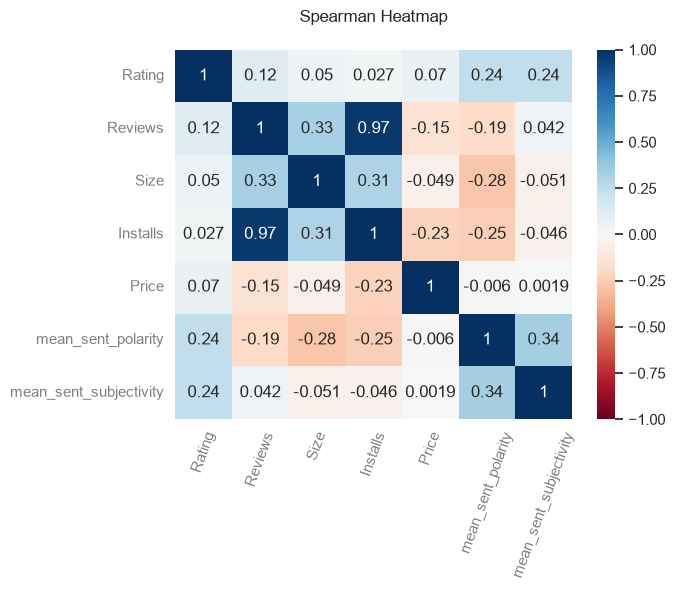

In [12]:
#pearson = df.corr(numeric_only=True, method='pearson')
spearman = df.corr(numeric_only=True, method='spearman')
sns.set_theme(style='darkgrid')

sns.heatmap(
            spearman,
            annot=True,
            cmap='RdBu',
            vmin=-1, vmax=1)


plt.title('Spearman Heatmap', pad=20)
plt.tick_params(axis='x', rotation=70, pad=2, colors='gray')
plt.tick_params(axis='y', rotation=0, pad=2, colors='gray')
plt.show()

<div style="color:#666;">

## Analisi correlazioni </div>

#### Correlazione positiva tra rating e reviews
##### Lo scatterplot conferma la relazione positiva (anche se leggera) osservata nella heatmap. Le applicazioni con rating più elevato tendono, in media, ad avere un numero maggiore di recensioni.
##### Nelle app con recensioni tra 4 e 4,7 è presente una leggera dispersione; mentre le app con valutazione uguale a 5 presentano poche recensioni

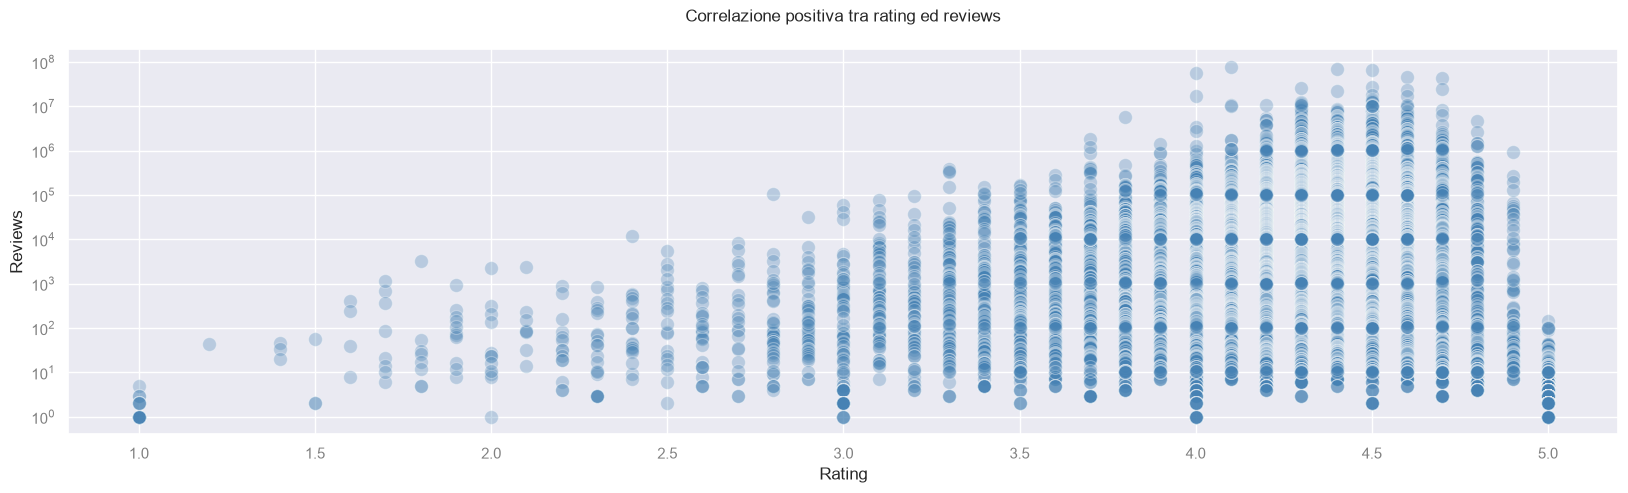

In [13]:
plt.figure(figsize = (20,5))

sns.scatterplot(
                data=df,
                x='Rating',
                y='Reviews',
                color='steelblue',
                alpha=0.3,
                s=100)

plt.title('Correlazione positiva tra rating ed reviews', pad=20)
plt.yscale('log')
plt.tick_params(axis='both', colors='gray')
plt.show()

<div style="color:#666;">

#### Correlazione positiva tra sentiment polarity e rating
##### Come visto nella heatmap si conferma l'esistenza di una correlazione positiva moderata tra sentiment polarity e rating; come nel grafico precedente esistono poche app con rating inferiore a 3, mentre la maggior parte delle app si concentrano tra un rating di 4 e 4,7.  All’aumentare del rating tende ad aumentare anche la sentiment polarity, sebbene con una certa dispersione dei valori. </div>

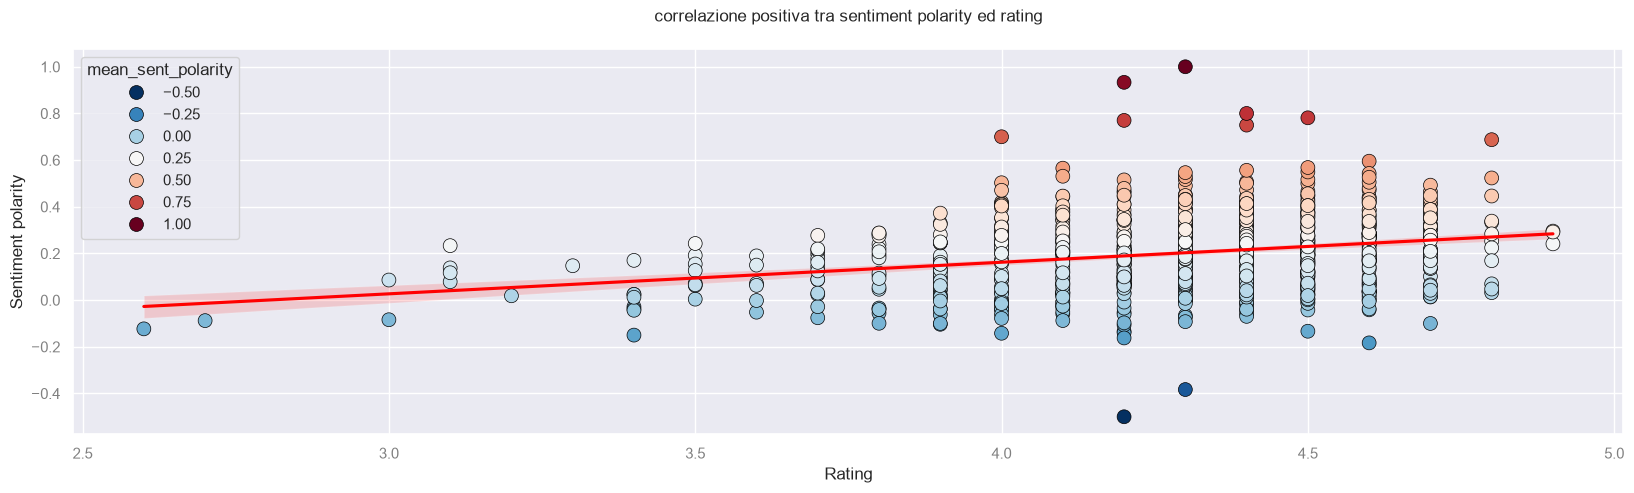

In [14]:
plt.figure(figsize = (20,5))

sns.regplot(
            data=df,
            x='Rating',
            y='mean_sent_polarity',
            scatter=False,
            line_kws={'color': 'red'})

sns.scatterplot(
                data=df,
                x='Rating',
                y='mean_sent_polarity',
                hue='mean_sent_polarity',
                edgecolor='black',
                linewidth=0.5,
                palette='RdBu_r',
                s=100)

plt.title('correlazione positiva tra sentiment polarity ed rating', pad=20)
plt.xlabel('Rating')
plt.ylabel('Sentiment polarity')
plt.tick_params(axis='both', colors='gray')
plt.show()

<div style="color:#666;">

#### Correlazione positiva tra reviews e size
##### La heatmap evidenziava una correlazione positiva di 0,3, ma questo dato è influenzato dalla presenza di pochi outlier sopra i 30 milioni di reviews, non dimostrandosi utile nonostante sia stato utilizzato il metodo spearman per la matrice di correlazione. </div>

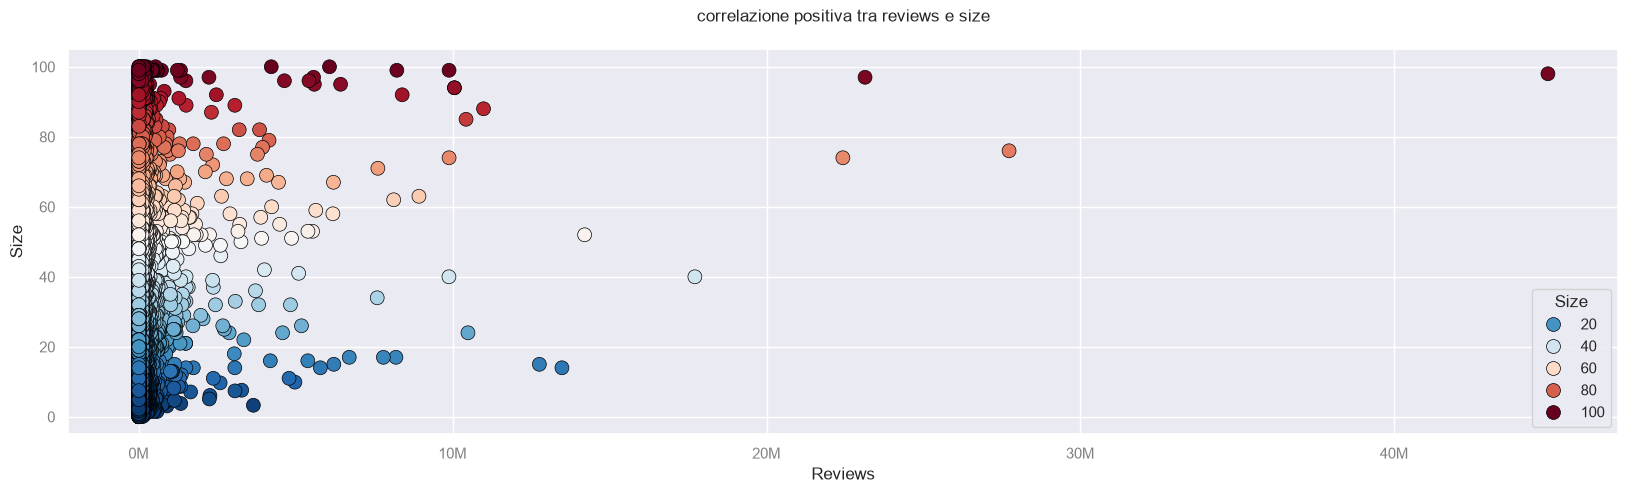

In [15]:
plt.figure(figsize = (20,5))

sns.scatterplot(
                data=df,
                x='Reviews',
                y='Size',
                hue='Size',
                edgecolor='black',
                linewidth=0.5,
                palette='RdBu_r',
                s=100)

# unità di misura in milioni
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

plt.title('correlazione positiva tra reviews e size', pad=20)
plt.xlabel('Reviews')
plt.ylabel('Size')
#plt.xscale('log')
#plt.yscale('log')
plt.tick_params(axis='both', colors='gray')
plt.show()

<div style="color:#666;">

#### Correlazione installs-reviews
##### La relazione positiva tra installazioni e recensioni è confermata dal grafico. All’aumentare del numero di installazioni cresce anche il numero di recensioni, con una distribuzione dei punti che segue un andamento crescente e ben definito. La correlazione di Spearman (0,97) risulta quindi coerente con quanto osservato nel grafico e indica una relazione molto forte.</div>

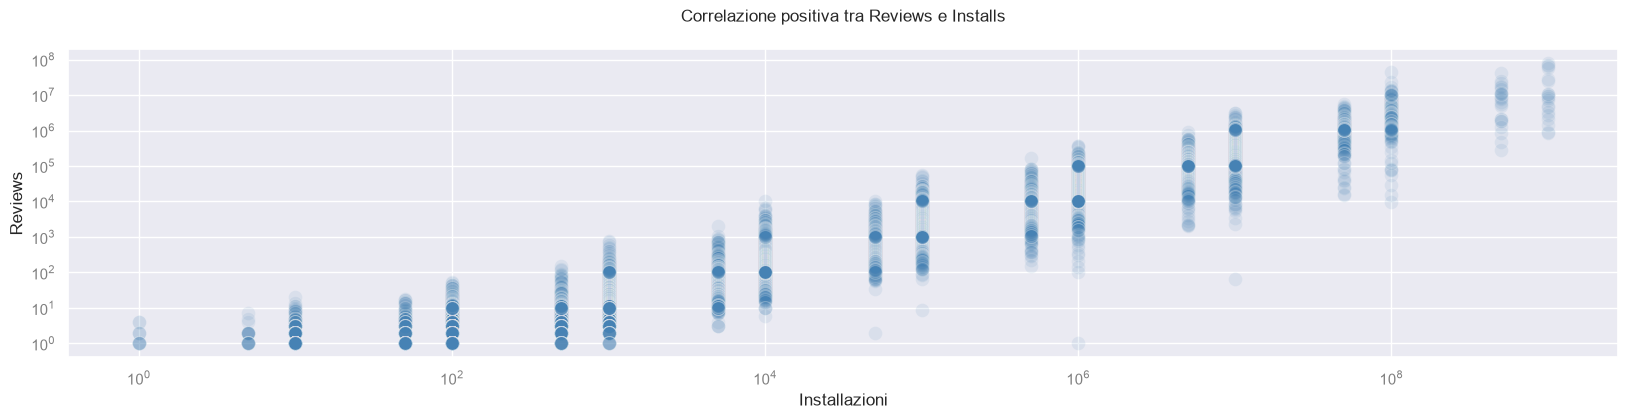

In [16]:
plt.figure(figsize=(20, 4))

sns.scatterplot(
            data=df,
            x='Installs',
            y='Reviews',
            s=100,
            alpha=0.1,
            color='steelblue')

# unità di misura in milioni
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

plt.title('Correlazione positiva tra Reviews e Installs', pad=20)
plt.xlabel('Installazioni')
plt.ylabel('Reviews')
plt.xscale('log')
plt.yscale('log')
plt.tick_params(axis='both', colors='gray')
plt.show()

<div style="color:#666;">

#### Correlazioni negative tra Reviews e Price/Sentiment polarity
#### Reviews / Price
##### La matrice evidenzia una relazione negativa debole (-0,15) tra Reviews e Price. Il grafico mostra che la relazione esiste, ma estremamente debole e non utile per individuare trend di mercato, mentre il p-value con valore di 0,00 mostra che la correlazione è statisticamente significativa e non casuale.

#### Reviews - sentiment polarity
##### La correlazione negativa (-0,19) tra Reviews e Sentiment polarity invece esiste a causa degli outlier che contribuiscono ad inclinare verso il basso la retta di regressione. La maggior parte delle applicazioni si concentra sotto i 20 milioni di reviews mentre quelle che contribuiscono a rendere la correlazione leggermente negativa si posizionano tra i 20 e gli 80 milioni di reviews. Anche qui il p-value di 0,00 mostra che non si tratta di una casualità.
</div>

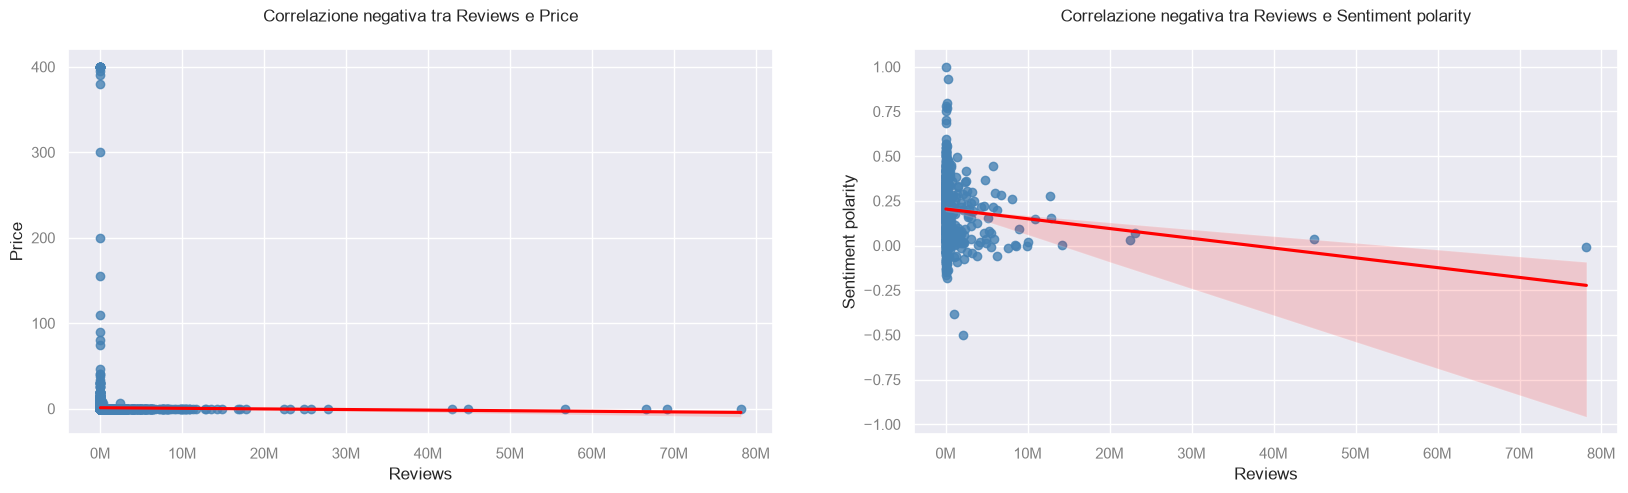

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

sns.regplot(
            data=df,
            x='Reviews',
            y='Price',
            ax=ax[0],
            color='steelblue',
            line_kws={'color':'red'})

# unità di misura in milioni
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

#ax[0].set_xscale('log')
#ax[0].set_yscale('log')
ax[0].set_title('Correlazione negativa tra Reviews e Price', pad=20)
ax[0].set_xlabel('Reviews')
ax[0].set_ylabel('Price')
ax[0].tick_params(axis='both', colors='gray')

#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

sns.regplot(
            data=df,
            x='Reviews',
            y='mean_sent_polarity',
            color='steelblue',
            ax=ax[1],
            line_kws={'color':'red'})

# unità di misura in milioni
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

ax[1].set_title('Correlazione negativa tra Reviews e Sentiment polarity', pad=20)
ax[1].set_xlabel('Reviews')
ax[1].set_ylabel('Sentiment polarity')
#ax[1].set_xscale('log')
#ax[1].set_yscale('log')
ax[1].tick_params(axis='both', colors='gray')
plt.show()

<div style="color:#666;">

#### P-value Reviews/Price </div>

In [18]:
from scipy.stats import spearmanr

_, p_value = spearmanr(df['Reviews'], df['Price'], nan_policy='omit')
print('P-value Reviews/Price: ',format(p_value, '.10f'))

P-value Reviews/Price:  0.0000000000


<div style="color:#666;">

#### P-value Reviews/Sentiment polarity </div>

In [19]:
_, p_value = spearmanr(df['Reviews'], df['mean_sent_polarity'],nan_policy='omit')
print('P-value Reviews/sentiment polarity: ',format(p_value, '.10f'))

P-value Reviews/sentiment polarity:  0.0000000342


<div style="color:#666;">

#### Correlazione positiva tra Size ed Installs
##### La matrice evidenzia una debole correlazione positiva (0,31) tra dimensione dell’app e numero di installazioni. Tuttavia, lo scatterplot mostra un’elevata dispersione dei dati e non evidenzia un chiaro trend crescente. Pertanto, la relazione risulta debole e di poca utilità. </div>

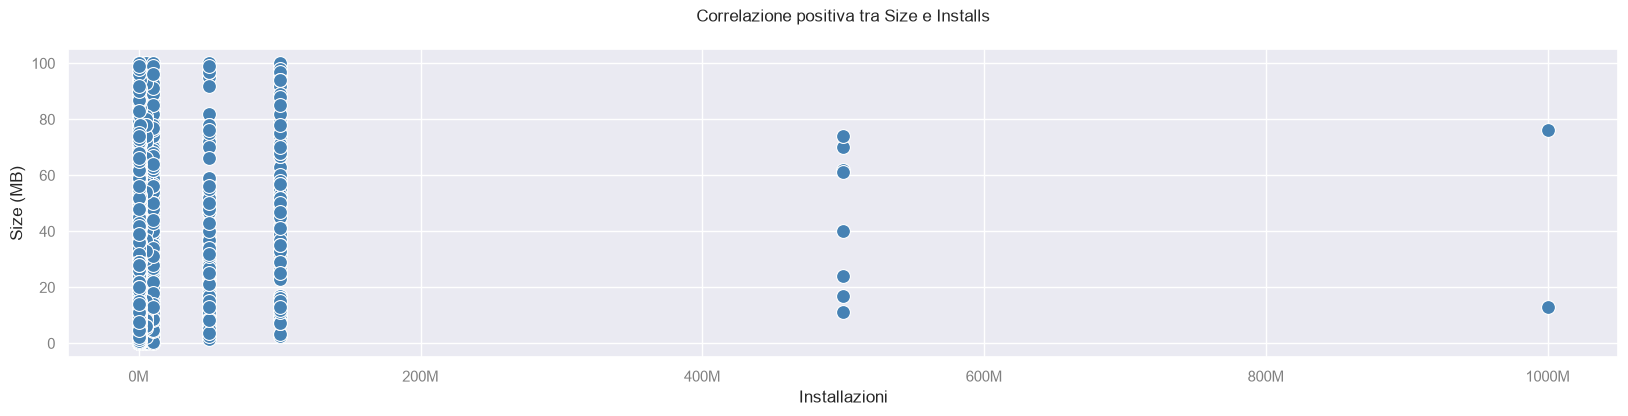

In [20]:
plt.figure(figsize=(20, 4))

sns.scatterplot(
                data=df,
                x='Installs',
                y='Size',
                color='steelblue',
                s=100)

# unità di misura in milioni
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

plt.title('Correlazione positiva tra Size e Installs', pad=20)
plt.xlabel('Installazioni')
plt.ylabel('Size (MB)')
#plt.xscale('log')
#plt.yscale('log')
plt.tick_params(axis='both', colors='gray')
plt.show()

<div style="color:#666;">

#### Correlazione negativa size e sentiment polarity
##### La heatmap mostra che esiste una correlazione negativa moderata (-0,28) tra la dimensione delle app e la media della sentiment polarity osservata nella heatmap. Analizzando la distribuzione emerge che la maggior parte delle app si concentra tra una media di sentiment polarity di 0 e 0,6, con size fino a 60 MB, le app con peso maggiore però presentano anche livelli di sentiment polarity più bassi ed in alcuni casi anche negativi (-0,1 e +0,4). Anche in questo caso risulta difficile affermare che la dimensione delle applicazioni influisca sul sentiment complessivo a causa della elevata dispersione e dalla mancanza di pattern visibili. </div>

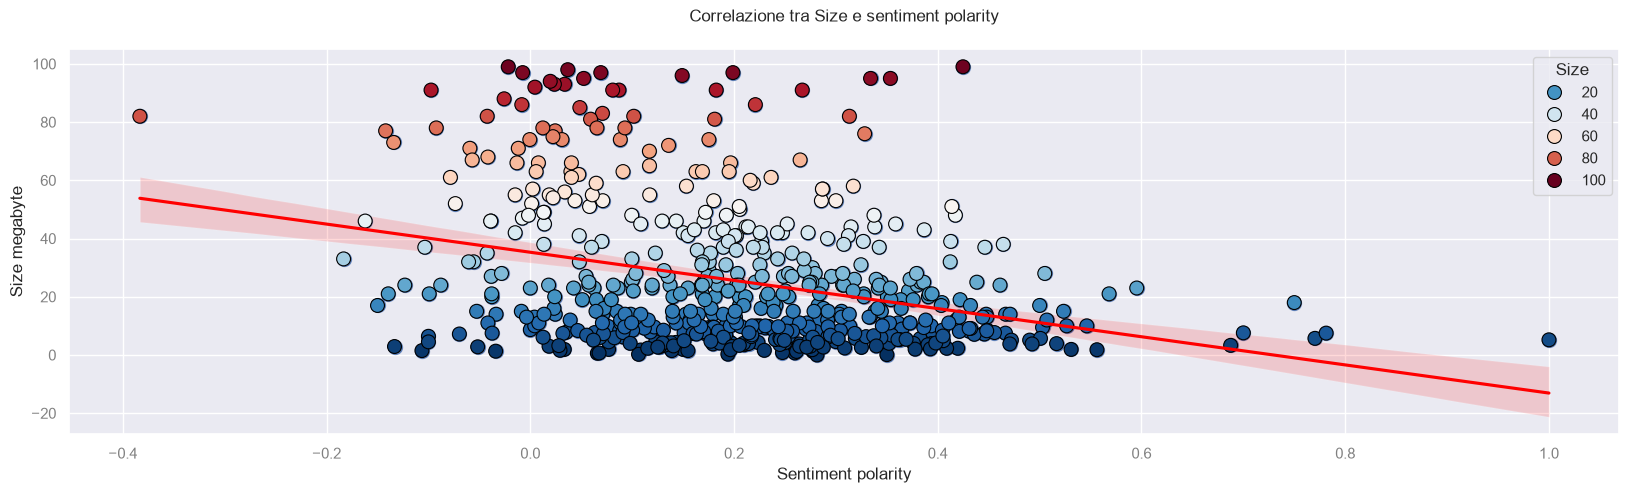

In [21]:
# subplt
fig, ax = plt.subplots(figsize=(20, 5))

# regressione
sns.regplot(
            data=df,
            x='mean_sent_polarity',
            y='Size',
            scatter_kws={'s':100},
            line_kws={'color':'red'})

# scatter
sns.scatterplot(
                data=df,
                x='mean_sent_polarity',
                y='Size',
                hue='Size',
                palette='RdBu_r',
                s=100,
                edgecolor='black')

plt.title('Correlazione tra Size e sentiment polarity', pad=20)
plt.ylabel('Size megabyte')
plt.xlabel('Sentiment polarity')
plt.tick_params(axis='both', colors='gray')
plt.show()

<div style="color:#666;">

#### Correlazioni tra Installs e price/sentiment polarity
#### Correlazione tra Installs e price
##### La correlazione negativa tra installs e price (-0,23) non viene evidenziata dal grafico in alcun modo, i prezzi delle app a pagamento sono correttamente distribuiti su tutti i livelli di installazioni, non emerge quindi un pattern evidente per guidare eventuali decisioni.
#### Correlazione tra Installs e Sentiment polarity
##### La maggior parte delle app si trova sotto i 200 milioni di installazioni ed il sentiment è mediamente positivo ed è situato tra 0 e 0.5, anche in questo caso i punti non seguono una tendenza chiara e non evidenziano trend utili.
</div>

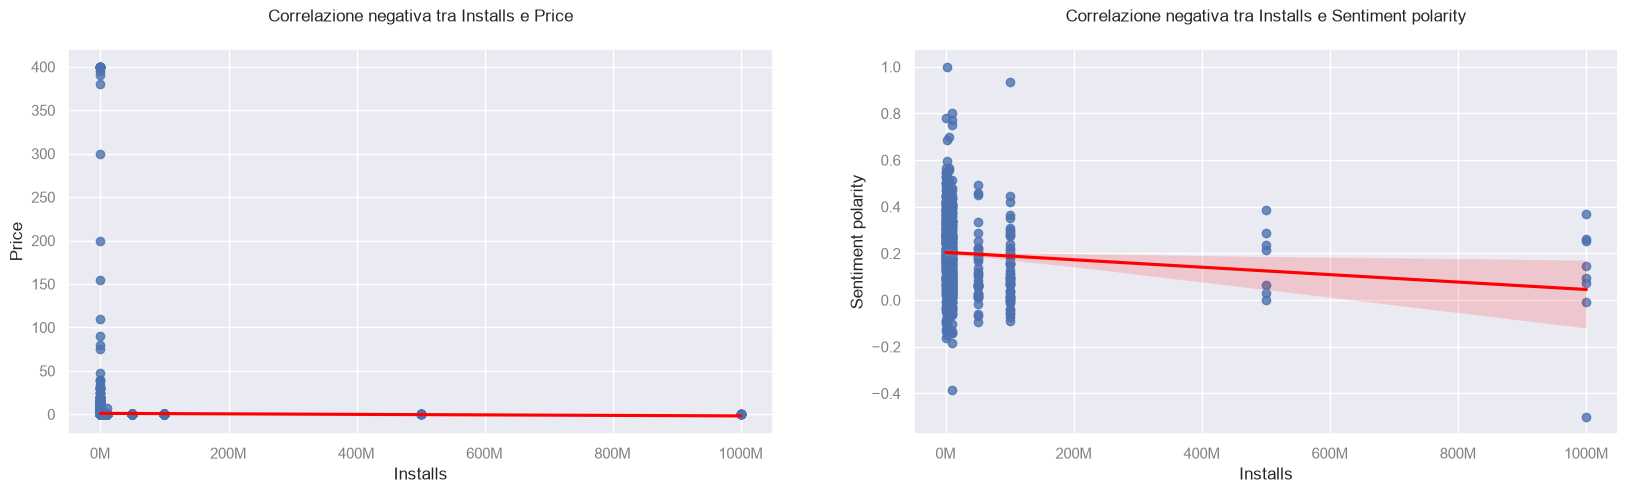

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
sns.regplot(
            data=df,
            x='Installs',
            y='Price',
            ax=ax[0],
            line_kws={'color':'red'})

# unità di misura in milioni
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

ax[0].set_title('Correlazione negativa tra Installs e Price', pad=20)
ax[0].set_xlabel('Installs')
ax[0].set_ylabel('Price')
#ax[0].set_xscale('log')
#ax[0].set_yscale('log')
ax[0].tick_params(axis='both', colors='gray')

#-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

sns.regplot(
            data=df,
            x='Installs',
            y='mean_sent_polarity',
            ax=ax[1],
            line_kws={'color':'red'})

# unità di misura in milioni
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))

ax[1].set_title('Correlazione negativa tra Installs e Sentiment polarity', pad=20)
ax[1].set_xlabel('Installs')
ax[1].set_ylabel('Sentiment polarity')
#ax[1].set_xscale('log')
#ax[1].set_yscale('log')
ax[1].tick_params(axis='both', colors='gray')
plt.show()

<div style="color:#666;">

## Analisi dataset </div>

<div style="color:#666;">

#### Categorie con media recensioni alta
##### le categorie Social, Communication, Game e Photography presentano il numero medio di recensioni più elevato. Per comprendere quali applicazioni contribuiscono maggiormente a questi risultati, sono state analizzate le app con il maggior numero di recensioni. Tra queste si distinguono Facebook, WhatsApp, Instagram, Messenger e YouTube, oltre a diversi videogiochi popolari come Subway Surfers, Clash of Clans e Clash Royale.
</div>

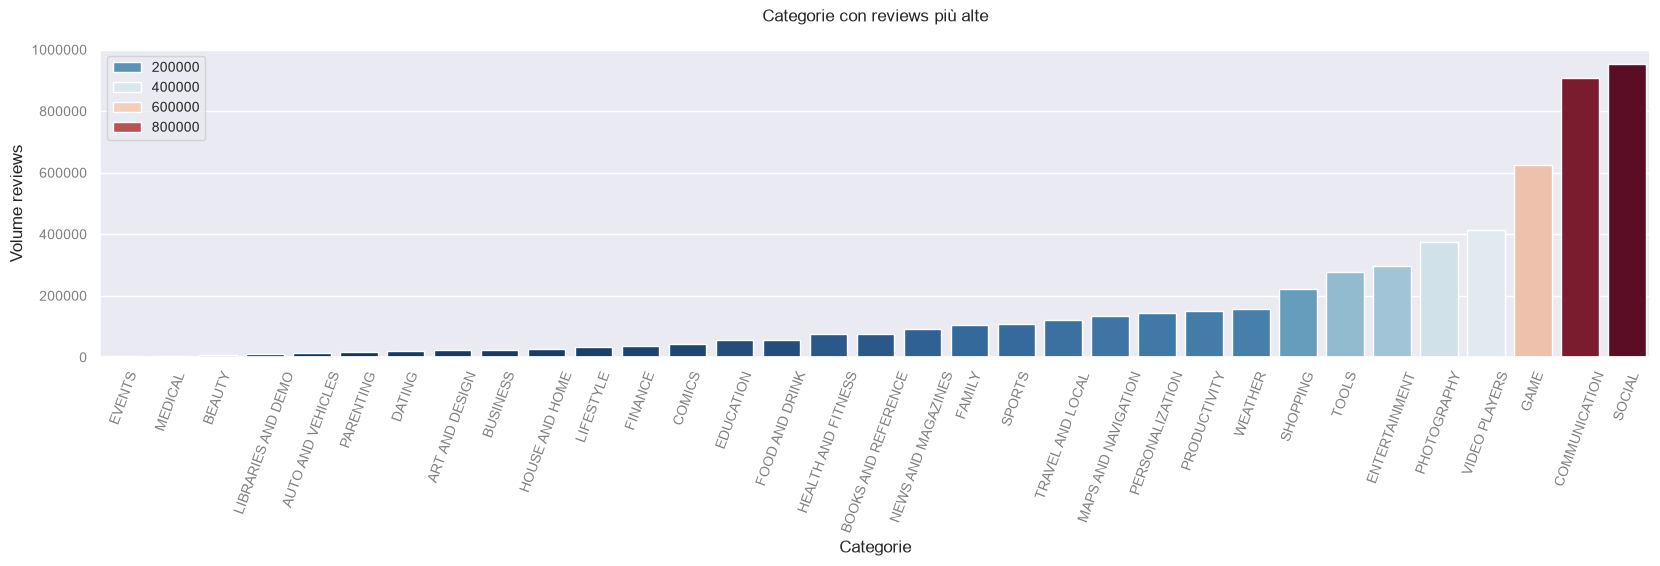

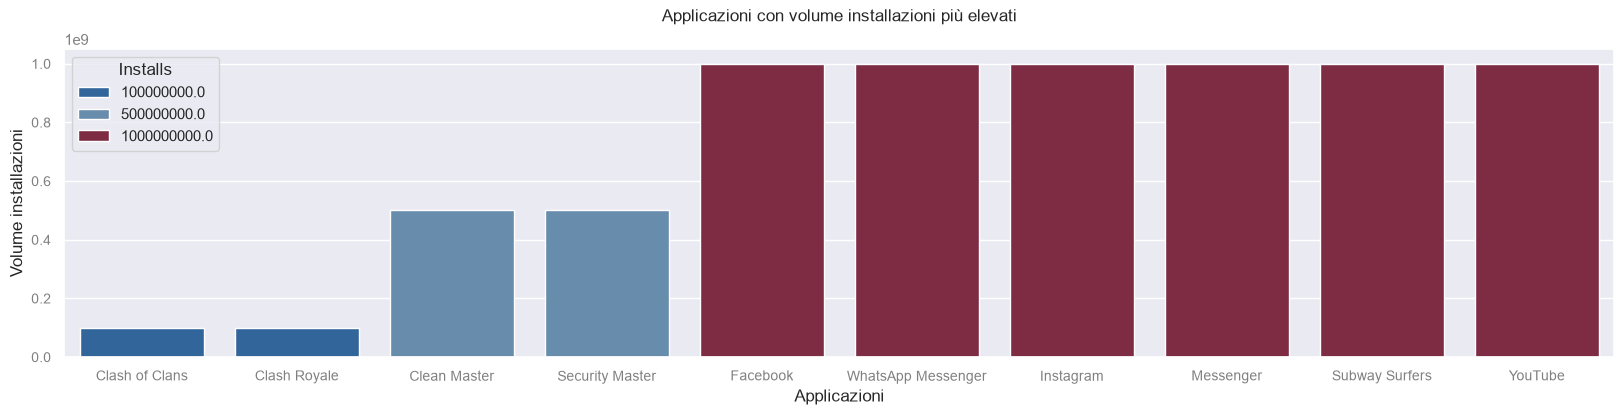

In [23]:
# classificazione categorie per reviews
classificazione = (df.groupby('Category')['Reviews'].mean().sort_values(ascending=True).reset_index())

plt.figure(figsize = (20,4))

sns.barplot(
            data=classificazione,
            x='Category',
            y='Reviews',
            hue='Reviews',
            palette='RdBu_r')

plt.title('Categorie con reviews più alte', pad=20)
plt.legend(fontsize=10)
plt.xlabel('Categorie')
plt.ylabel('Volume reviews')
plt.xticks(rotation=70, fontsize=10)
plt.yticks(fontsize=10)
plt.ticklabel_format(style='plain', axis='y') # disattivazione notazione scientifica
plt.tick_params(axis='both', colors='gray')

# -------------------------------------------------------------------------------------------------------------------------------------------------

# fix len nomi
df['app_short'] = df['App'].replace({
    # grafico app con più installazioni
    'Messenger – Text and Video Chat for Free': 'Messenger',
    'Security Master- Antivirus, VPN, AppLock, Booster': 'Security Master',
    'Clean Master- Space Cleaner & Antivirus': 'Clean Master',
    'Whatsapp Messenger': 'Whatsapp',
    # grafico app più costose nel play store
    'Security Master - Antivirus, VPN, AppLock, Booster': 'Security Master',
    'Human Anatomy Atlas 2018: Complete 3D Human Body': 'Human Anatomy Atlas 2018',
    'Muscle Premium - Human Anatomy, Kinesiology, Bones': 'Muscle Premium'})


# classificazione app per installazioni
reviews = df.nlargest(10, 'Reviews')[['app_short', 'Category', 'Installs']].sort_values(by='Installs', ascending=True)

plt.figure(figsize=(20,4))
palette = { # creazione palette con aiuto IA
    100000000.0: '#2166AC',   # blu
    500000000.0: '#5B8DB8',   # blu medio
    1000000000.0: '#8B1E3F'   # rosso
}

sns.barplot(
            data=reviews,
            x='app_short',
            y='Installs',
            hue='Installs',
            palette = palette)

plt.title('Applicazioni con volume installazioni più elevati', pad=20)
plt.xlabel('Applicazioni')
plt.ylabel('Volume installazioni')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tick_params(axis='both', colors='gray')
plt.show()

<div style="color:#666;">

#### Distribuzione delle applicazioni per fascia d'età
##### la maggior parte delle applicazioni presenti nel dataset è classificata come Everyone, risultando quindi adatta a utenti di tutte le età. La seconda categoria più rappresentata è Teen, con circa 1.000 applicazioni. Le categorie Mature 17+ ed Everyone 10+ sono meno frequenti, mentre le applicazioni destinate esclusivamente a un pubblico adulto rappresentano una quota molto ridotta del dataset. </div>

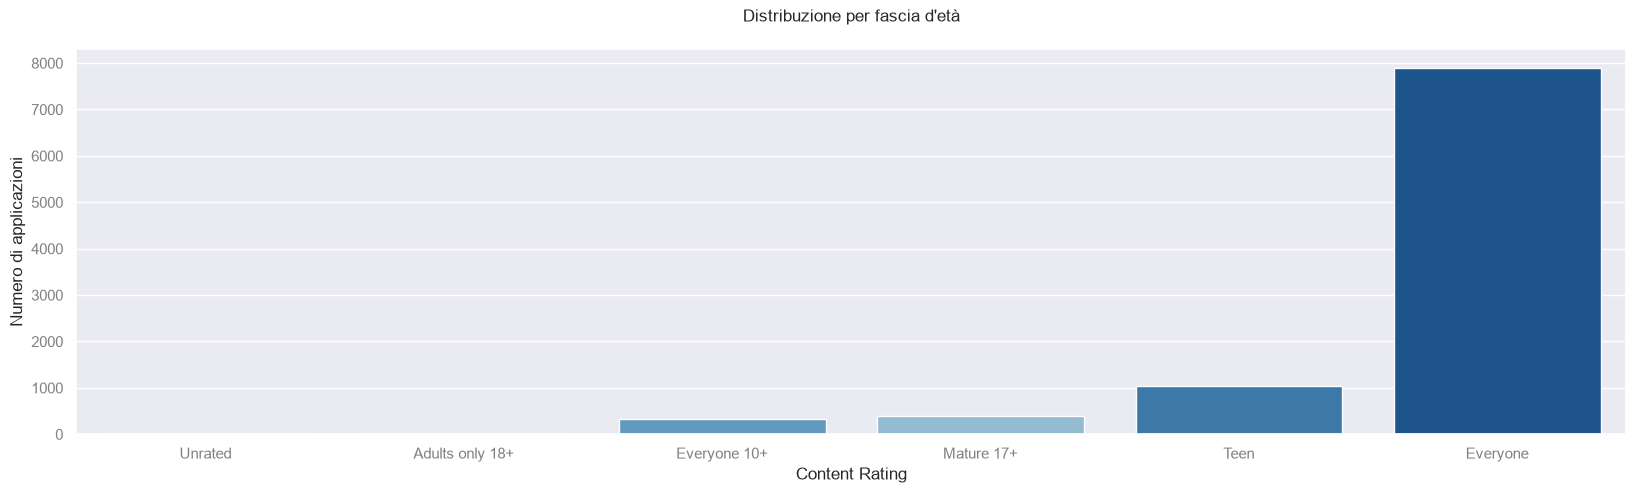

In [24]:
ordine = df['Content Rating'].value_counts().sort_values().index
plt.figure(figsize=(20,5))

sns.countplot(
                data=df,
                x='Content Rating',
                hue='Content Rating',
                palette='Blues_r',
                order=ordine)

plt.title("Distribuzione per fascia d'età", pad=20)
plt.ylabel('Numero di applicazioni')
plt.tick_params(axis='both', colors='gray')
plt.show()

<div style="color:#666;">

#### Categorie più presenti nel play store
##### Per confrontare i prezzi tra le categorie è stato usato il 95° percentile per ridurre influenza dei valori estremi. Le categorie individuate nella top 10 risultano essere le più presenti nel play store. Considerando esclusivamente le applicazioni a pagamento, si osservano differenze nel prezzo tra le categorie, suggerendo strategie di monetizzazione differenti a seconda del settore. </div>

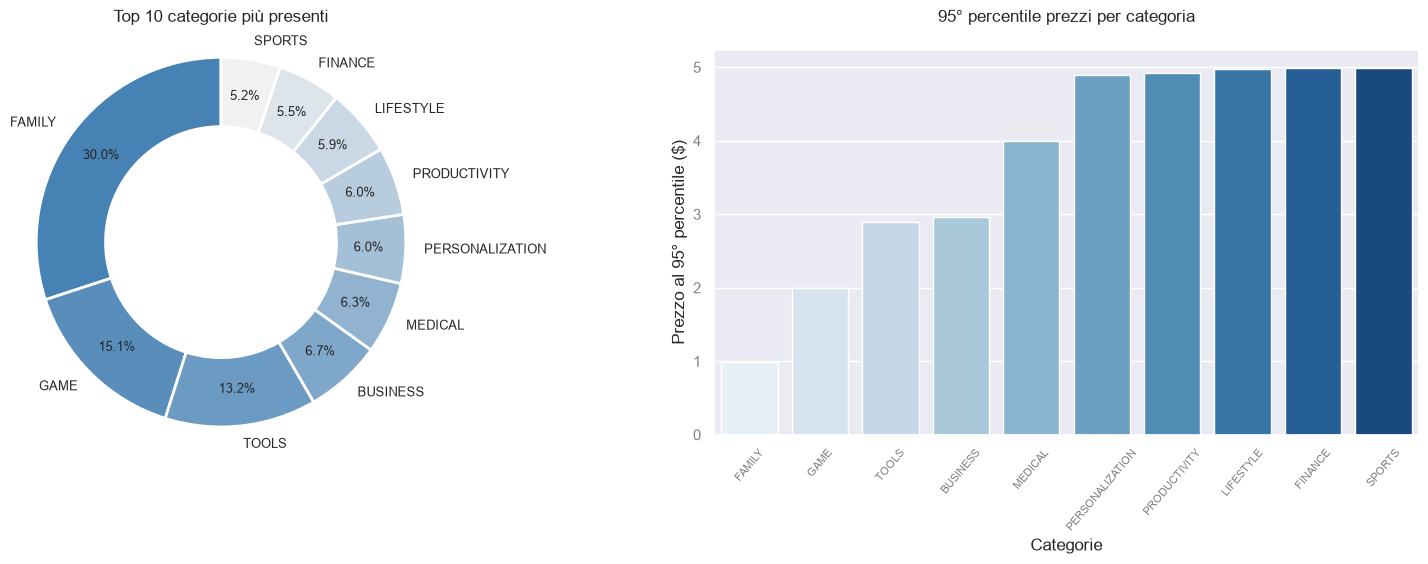

In [25]:
category_count = df['Category'].value_counts()
top_category = category_count.head(10)

# pieplot
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
colors = sns.color_palette("light:steelblue_r", len(top_category))
ax[0].set_title('Top 10 categorie più presenti', pad=20)

ax[0].pie(
            top_category.values,
            colors=colors,
            labels=top_category.index,
            autopct='%1.1f%%',
            radius=1.2,
            pctdistance=0.80,
            startangle=90,
            textprops={'fontsize': 9},
            wedgeprops={'width': 0.45, 'edgecolor': 'white', 'linewidth': 2})

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------

# barplot
tot_categorie = (df[df['Price'] > 0].groupby('Category')['Price'].quantile(0.95).sort_values(ascending=True).head(10))

sns.barplot(
            x=top_category.index,
            y=tot_categorie,
            ax=ax[1],
            hue=top_category.index,
            palette='Blues')

ax[1].set_title('95° percentile prezzi per categoria', pad=20)
ax[1].set_xlabel('Categorie')
ax[1].set_ylabel('Prezzo al 95° percentile ($)')
plt.xticks(rotation=50, fontsize=8)
plt.tick_params(axis='both', colors='gray')
plt.show()

<div style="color:#666;">

##### Le categorie più presenti nel dataset non risultano essere però quelle con il rating medio più elevato. Tuttavia, molte delle categorie meglio valutate contengono poche applicazioni, mentre altre più numerose mostrano un rating medio leggermente più basso ma più rappresentativo. </div>

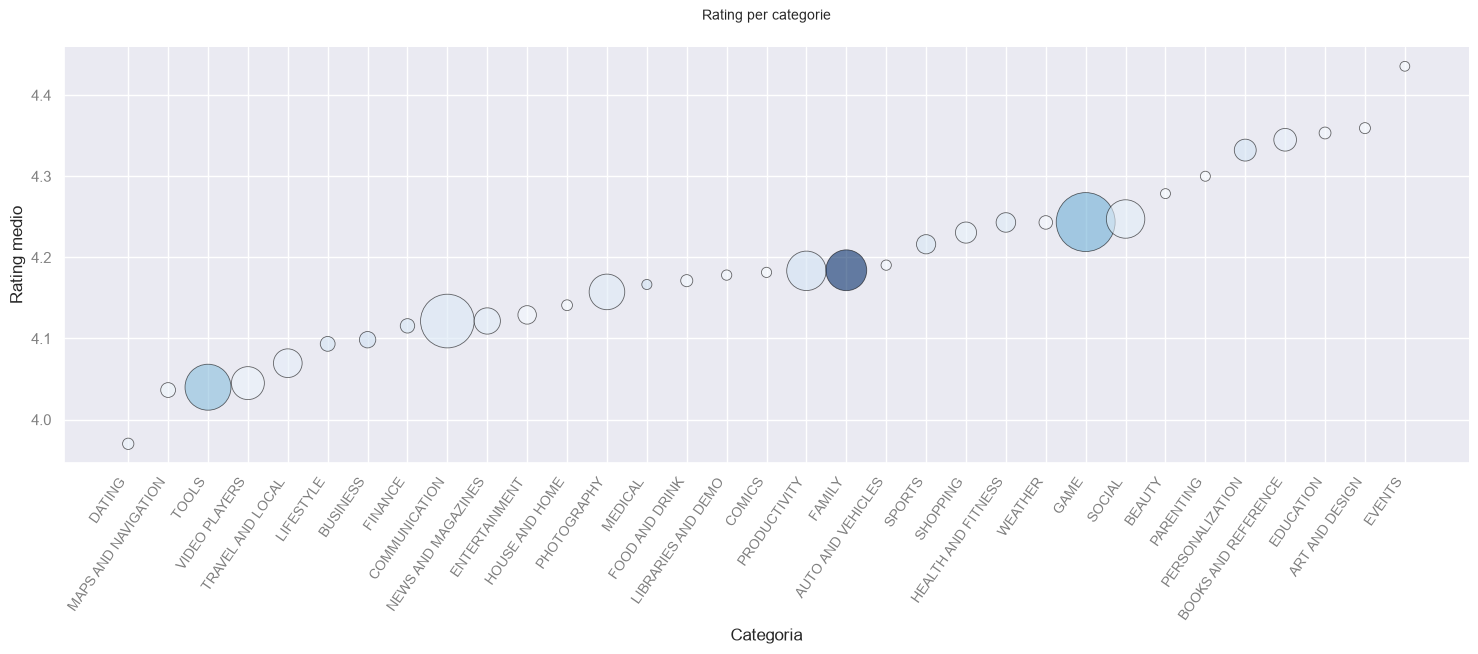

In [26]:
rating = (df.groupby('Category').agg(
        Rating_Medio=('Rating', 'mean'),
        Numero_App=('App', 'count'),
        installazioni=('Installs', 'sum')
    ).sort_values('Rating_Medio', ascending=True).reset_index())


grafico = sns.relplot(
                        data=rating,
                        x='Category',
                        y='Rating_Medio',
                        hue='Numero_App',
                        height=5,
                        aspect=3,
                        alpha=0.6,
                        edgecolor='black',
                        palette='Blues',
                        size='installazioni',
                        sizes=(50, 1800))

grafico.legend.remove()
plt.title('Rating per categorie', loc='center', fontsize=10, pad=20)
plt.xlabel('Categoria')
plt.ylabel('Rating medio')
plt.xticks(rotation=55, ha='right', fontsize=10)
plt.tick_params(axis='both', colors='gray')
plt.show()

<div style="color:#666;">

#### Analisi apps Free vs paid
##### Le applicazioni a pagamento con maggiori volumi sono distribuite nelle categorie: family, game, tools, medical e personalization; insieme vanno a comporre solamente il 7,8% di google play store. Le app gratuite sono invece il 92.1%. </div>

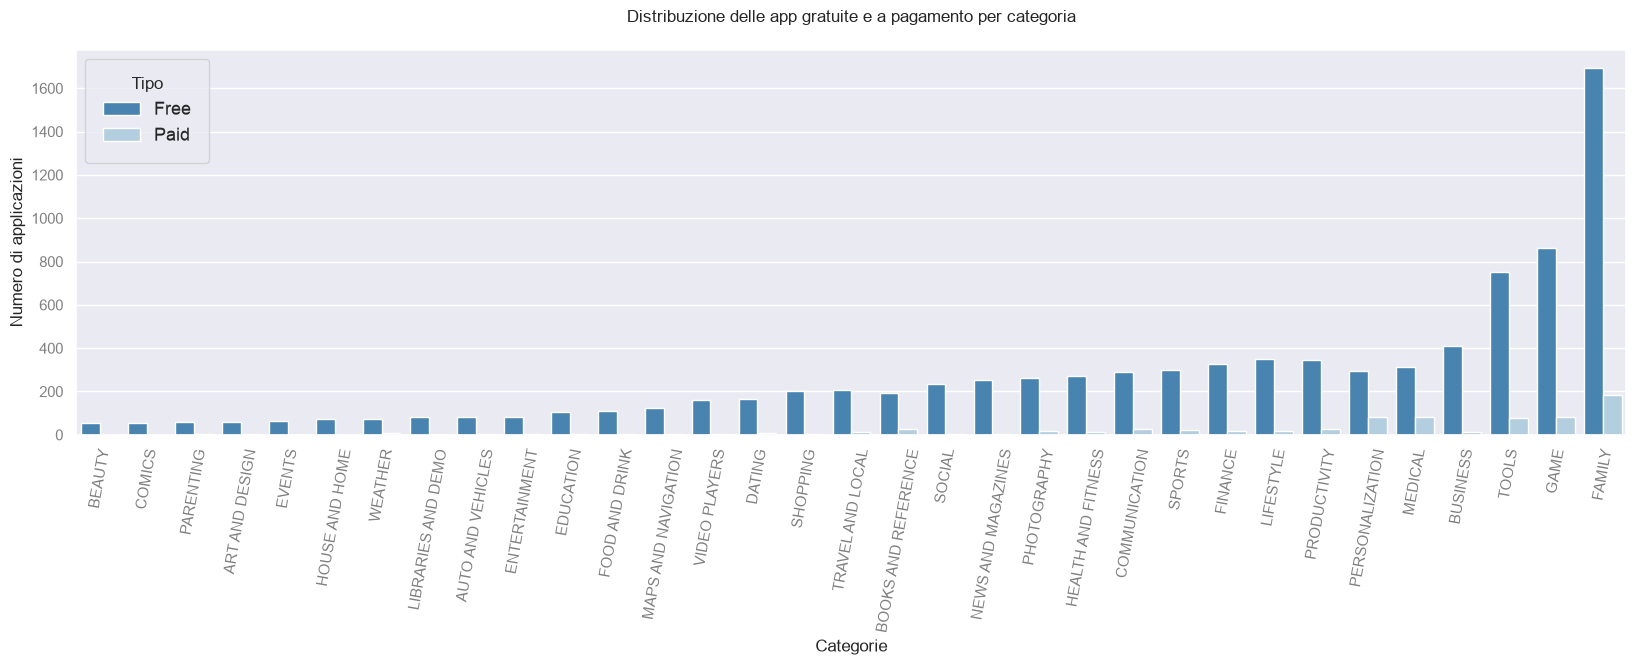

In [27]:
count_app = (df.groupby(['Category', 'Type']).size().reset_index(name='Count'))
ordine = (count_app.groupby('Category')['Count'].sum().sort_values(ascending=True).index)

plt.figure(figsize=(20,5))

sns.barplot(
            data=count_app,
            x='Category',
            y='Count',
            hue='Type',
            palette='Blues_r',
            order=ordine)

plt.title('Distribuzione delle app gratuite e a pagamento per categoria', pad=20)
plt.xlabel('Categorie')
plt.ylabel('Numero di applicazioni')
plt.xticks(rotation=80)
plt.tick_params(axis='both', colors='gray')
plt.legend(title='Tipo', markerscale=1, borderpad=1, fontsize=13)

plt.show()

<div style="color:#666;">

#### Ricerca concentrazione app per fascia di prezzo
##### È stata rilevata la fascia di prezzo delle app sotto i 25 euro con il 95° percentile, evitando la scelta di una soglia arbitraria e restando relativamente vicino alla media dei prezzi.
</div>

In [28]:
# ricerca fascia di prezzo
q95 = df[df['Price'] > 0]['Price'].quantile(0.95)
print('95° percentile: ', q95)

# ricerca media dei prezzi
media_prezzi = (df[df['Price']>0]['Price'].mean())
print('Media prezzi: ', media_prezzi)

95° percentile:  24.99
Media prezzi:  14.045145502645504


<div style="color:#666;">

#### Esplorazione outlier delle applicazioni a pagamento
##### Le applicazioni a pagamento si concentrano principalmente nella fascia di prezzo compresa tra 0 e circa 25 euro. Al di sopra del 95° percentile sono presenti pochi outlier, con prezzi compresi tra 25 e 400 euro, evidenziati nel grafico dalla banda blu. È stato utilizzato il 95° percentile perchè gli outlier si trovano tutti sopra il 95% dei dati, l'interquartile range avrebbe escluso invece numerose applicazioni concentrate nella fascia 0-25 Euro, sfalsando le analisi.

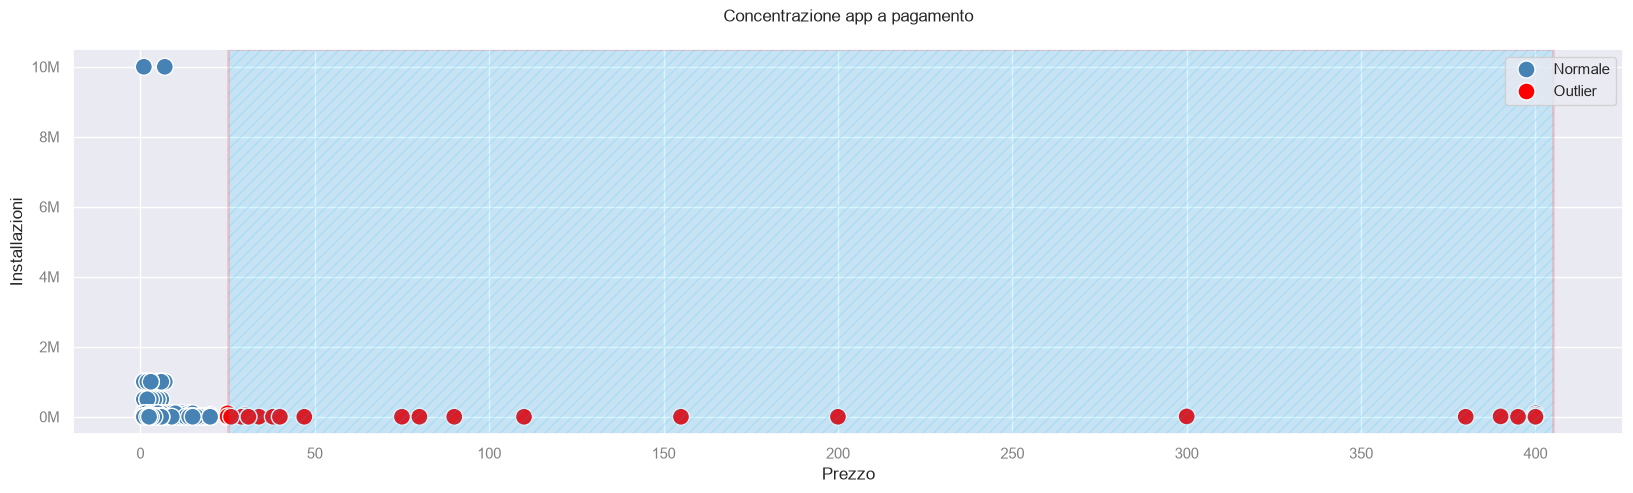

In [29]:
q95 = df[df['Price'] > 0]['Price'].quantile(0.95)
otlr= df[df['Price'] > 0].assign(Outlier=lambda x: np.where(x['Price'] >= q95, 'Outlier', 'Normale'))

plt.figure(figsize=(20, 5))

sns.scatterplot(
                data=otlr,
                x='Price',
                y='Installs',
                s=150,
                hue='Outlier',
                palette={'Outlier': 'red',
                         'Normale':'steelblue'})

# banda azzurra / fascia di prezzo 25-400 €
span = plt.axvspan(
                    24.99,
                    405,
                    color='deepskyblue',
                    alpha=0.15)
span.set_hatch('///')
span.set_edgecolor('red')
span.set_linewidth(2)

# unità di misura in milioni
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.0f}M'))

plt.title('Concentrazione app a pagamento', pad=20)
plt.legend(loc='upper right')
plt.xlabel('Prezzo')
plt.ylabel('Installazioni')
#plt.yscale # conflitto con etichette in milioni
plt.tick_params(axis='both', colors='gray')
plt.show()

<div style="color:#666;">

#### Esplorazione applicazioni a pagamento con prezzo superiore alla media
##### Le app con i prezzi più elevati appartengono prevalentemente alla serie “I’m Rich”, una categoria di app simboliche o dimostrative, prive di funzionalità particolarmente rilevanti e commercializzate a prezzi estremamente elevati. Tra queste spicca “I’m Rich - Trump Edition”, che rappresenta l’applicazione più costosa del dataset con un prezzo di 400 dollari. </div>

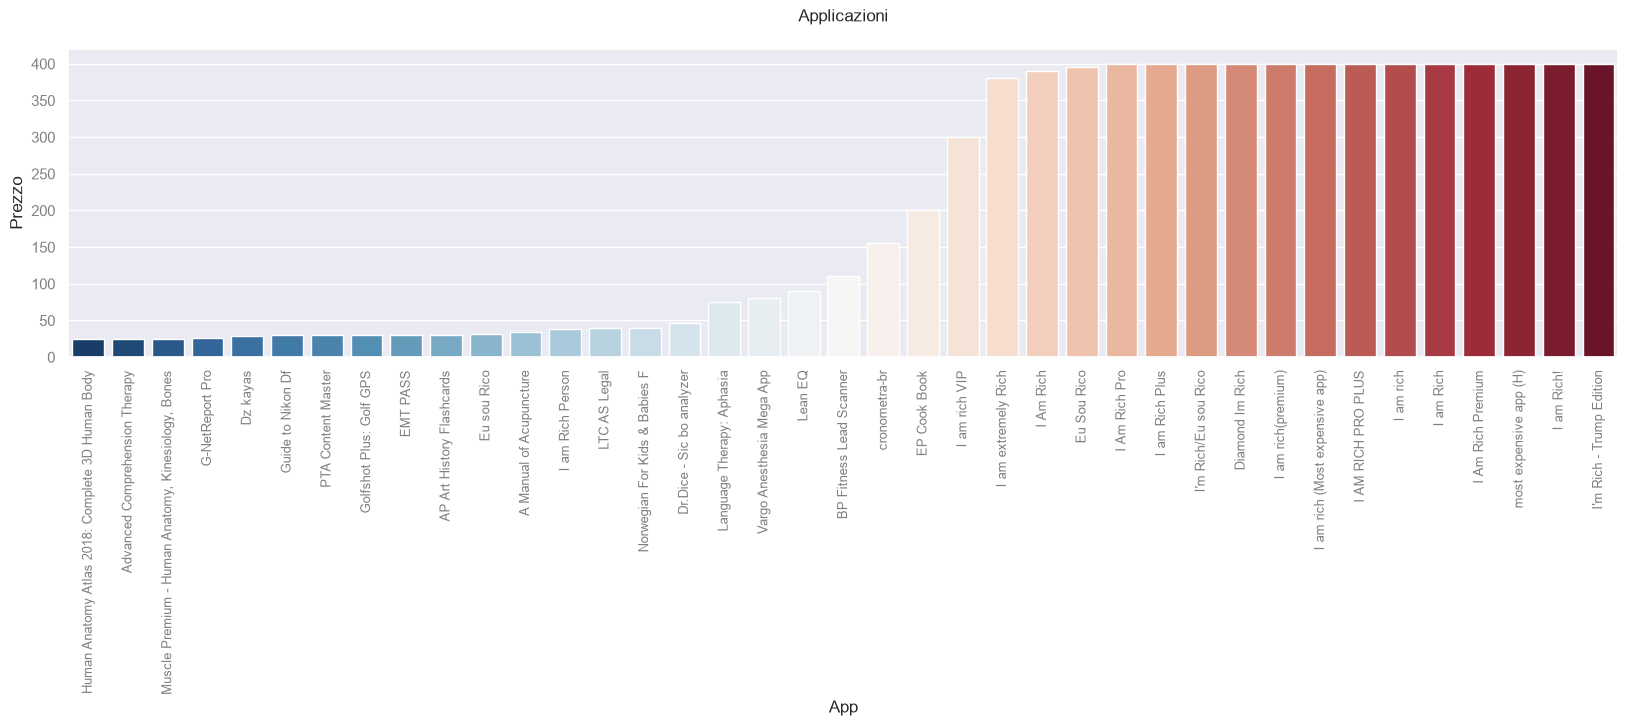

In [30]:
# ricerca prezzo medio e filtraggio solo su app con prezzo >= alla media
app_95p = (df[df['Price'] >= q95][['App', 'Price']].sort_values(by='Price', ascending=True).reset_index())

plt.figure(figsize=(20,4))
sns.barplot(
            data=app_95p,
            x='App',
            y='Price',
            palette='RdBu_r',
            hue='App')

plt.title('Applicazioni', pad=20)
plt.xlabel('App')
plt.ylabel('Prezzo')
plt.xticks(rotation=90, fontsize=9)
plt.tick_params(axis='both', colors='gray')
plt.show()

<div style="color:#666;">

#### Conteggio app free e paid </div>

In [31]:
df['Type'].value_counts(normalize=True).mul(100).round(1)

Type
Free    92.2
Paid     7.8
Name: proportion, dtype: float64

<div style="color:#666;">

#### Ricerca app più costosa </div>

In [32]:
df.nlargest(1, 'Price')[['App', 'Price']].sort_values(by='Price', ascending=False)

,App,Price
3913,I'm Rich - Trump Edition,400.0


<div style="color:#666;">

#### Ricerca posizione di mercato

##### Per la ricerca di un mercato potenziale i dati sono stati filtrati in base alle categorie inferiori al 75° percentile, dove al di sotto si trovano categorie non dominate da aziende con forte posizionamento e mercati saturi. Sono state incluse tutte le categorie etichettate come "Everyone" e "Teen" essendo la parte dominante del play store, avendo così modo di evitare nicchie.
##### Successivamente sono state filtrate con 25° percentile le categorie con un basso volume di installazioni e quindi con poco mercato, sono state mantenute quelle con sentiment analysis positiva con valori di almeno 0.2
</div>

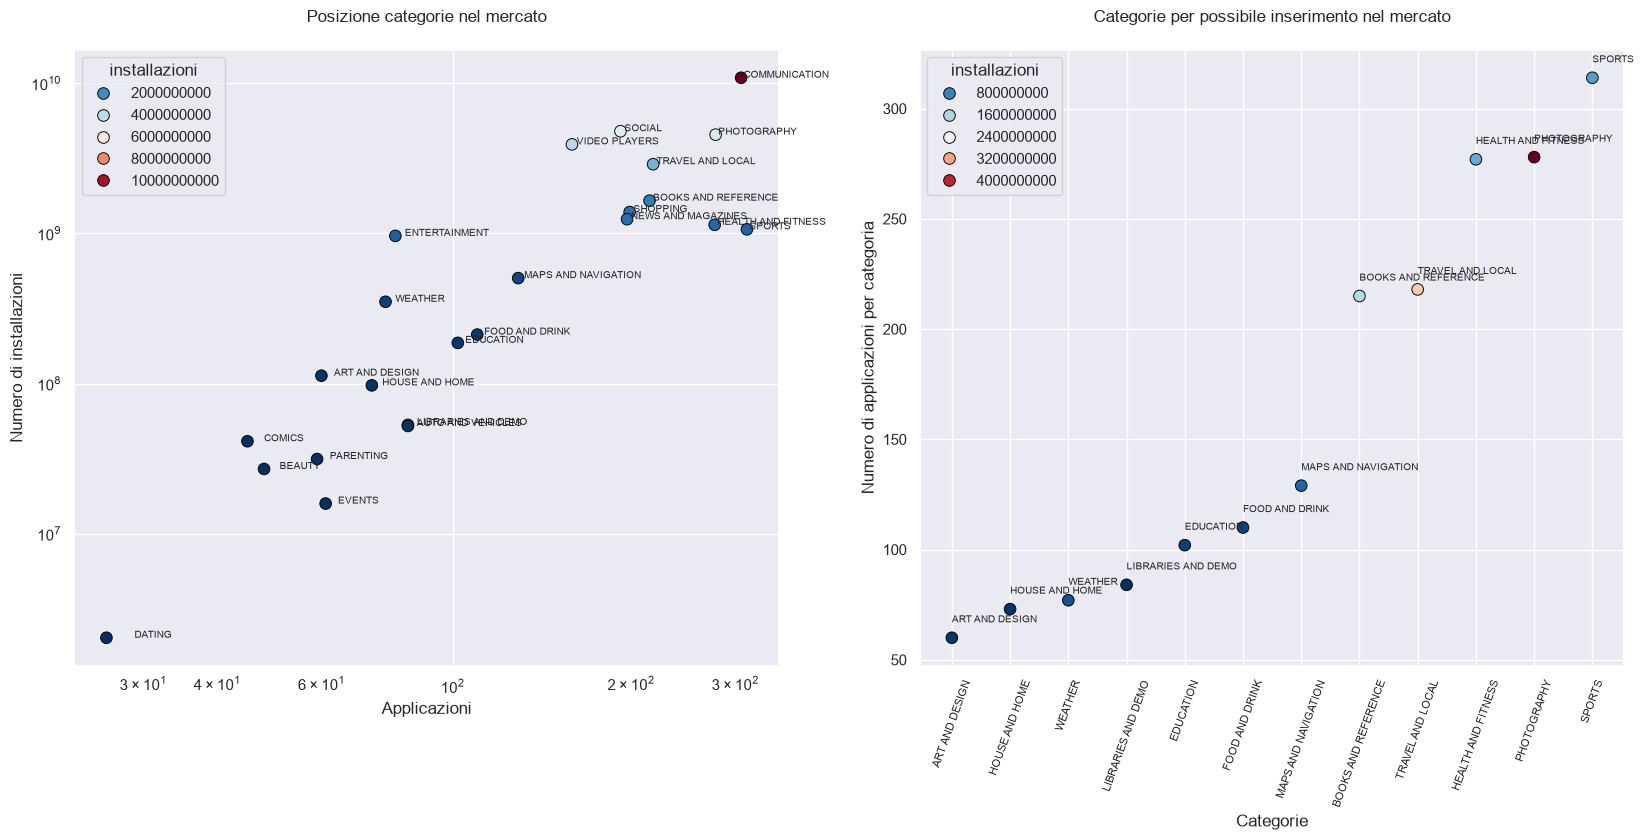

In [33]:
mkt = (df[
        (df['Content Rating']=='Everyone') | (df['Content Rating']=='Teen')
        ].groupby('Category').agg(
            tot_app=('App', 'count'),
            installazioni=('Installs', 'sum'),
            sentiment=('mean_sent_polarity', 'mean')
        ).sort_values('installazioni', ascending=False).reset_index())

q75 = mkt['tot_app'].quantile(0.75)
mkt = mkt[mkt['tot_app'] < q75]

#   --- SCATTER 1
fig, ax = plt.subplots(1,2, figsize=(20,8))
ax[0].set_title('Posizione categorie nel mercato', pad=20)
ax[0].set_xlabel('Applicazioni')
ax[0].set_ylabel('Numero di installazioni')
ax[0].set_xscale('log')
ax[0].set_yscale('log')

sctr = sns.scatterplot(
                        data=mkt,
                        x='tot_app',
                        y='installazioni',
                        s=70,
                        edgecolor='black',
                        hue='installazioni',
                        palette='RdBu_r',
                        ax=ax[0])

for _, row in mkt.iterrows():
    sctr.text(
                row['tot_app'] + 3,
                row['installazioni'],
                row['Category'],
                fontsize=7,
                ha='left')


# --------------------------------------------------------------------------------------------------------------------------------------------------------------


#   --- SCATTER 2
q25 = mkt['installazioni'].quantile(0.25)
mercato = (mkt[(mkt['tot_app'] <= q75) & (mkt['installazioni'] > q25) & (mkt['sentiment'] > 0.2)].sort_values(by='tot_app',ascending=True))

plt.xticks(rotation=70, fontsize=8)
ax[1].set_title('Categorie per possibile inserimento nel mercato', pad=20)
ax[1].set_xlabel('Categorie')
ax[1].set_ylabel('Numero di applicazioni per categoria')
#ax[1].set_xscale('log')
#ax[1].set_yscale('log')

mkt_filter = (sns.scatterplot(
                                data=mercato,
                                x='Category',
                                y='tot_app',
                                hue='installazioni',
                                palette='RdBu_r',
                                s=70,
                                edgecolors='black',
                                ax=ax[1]))

for _, row in mercato.iterrows():
    ax[1].text(
                row['Category'],
                row['tot_app'] + 7,
                row['Category'],
                fontsize=7,
                ha='left')

plt.show()

<div style="color:#666;">

#### Selezione categorie con migliori opportunità per ingresso sul mercato
##### Le categorie individuate presentano un buon equilibrio tra il numero di installazioni ed app presenti nella categoria andando così a ridurre il livello di concorrenza; inoltre presentano anche livelli di sentiment positivo. In particolare: Art & Design, House & Home, Weather, Libraries & Demo ed Education si configurano come potenziale opportunità per il lancio di nuove applicazioni rispetto alle rimanenti, avendo un numero inferiore di app presenti nella categoria.
</div>

In [34]:
mercato[['Category', 'tot_app']].head(10)

,Category,tot_app
23,ART AND DESIGN,60
24,HOUSE AND HOME,73
20,WEATHER,77
25,LIBRARIES AND DEMO,84
22,EDUCATION,102
21,FOOD AND DRINK,110
17,MAPS AND NAVIGATION,129
9,BOOKS AND REFERENCE,215
8,TRAVEL AND LOCAL,218
13,HEALTH AND FITNESS,277


<div style="color:#666;">

#### Conclusioni
##### L’analisi del Google Play Store mostra un mercato fortemente concentrato nelle categorie Family, Game e Tools, caratterizzate da un’elevata concorrenza. Le applicazioni a pagamento presentano prevalentemente prezzi inferiori ai 25 dollari, mentre valori superiori costituiscono casi eccezionali. L’integrazione delle informazioni relative a installazioni, numero di applicazioni e sentiment ha consentito di individuare alcune categorie che presentano un equilibrio favorevole tra domanda, competizione e soddisfazione degli utenti, rappresentando potenziali opportunità per il lancio di nuove applicazioni.
</div>